# Demo model development


### Create a DemoModel with a pulsar and a blazar 

2 total sources: 6 free parameters
Model: [like3.sources.PointSource: 
	name  : Pulsar
	ICRS  : SkyDir(0.000, 0.000)
	model : PLSuperExpCutoff4
		Norm      : 1e-11 
		Index     : 2 
		Curvature : 0.7 
		b         : 0.69 (FROZEN), like3.sources.PointSource: 
	name  : Blazar
	ICRS  : SkyDir(0.000, 0.000)
	model : LogParabola
		Norm      : 4e-12 
		Index     : 2 
		beta      : 0 
		E_break   : 1e+03 (FROZEN)]


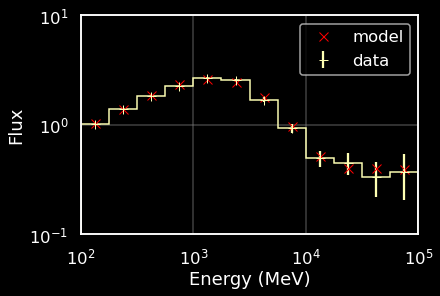

### Now use Likelihood framework to fit the model to the data

Name                  index     value  error(%)  gradient        TS
Pulsar_Norm               0 9.882e-12      13.2       6.1     29485
      _Index              1     1.993       1.3       4.3          
      _Curvature          2    0.7015      18.3      -5.4          
Blazar_Norm               3 4.051e-12      78.6       4.0      3343
      _Index              4     2.019       1.9       1.6          
      _beta               5 0.0008114    7712.2      -2.7          


In [18]:
%reset -f
%run pylib/tools dark
from utilities.ipynb_docgen import show
from importlib import reload
from like3 import likelihood as lk; reload(lk)
from like3 import demo_model as dm; reload(dm)

show(f"""### Create a DemoModel with a pulsar and a blazar """)

model = dm.DemoModel.test(plot=True, src_key=3, random_state=42)

show(f""" ### Now use Likelihood framework to fit the model to the data""")
self = lk.Likelihood(model=model, data=model.data)
self.maximize(model.values)
self.summary()
